# Telco Customer Churn: Exploratory Data Analysis

## Objective

This notebook explores IBM's Telco Customer Churn dataset to understand the customer characteristics associated with churn and identify data-quality issues that must be addressed before modeling.

The target variable is `Churn`:

- `Yes`: the customer left the company
- `No`: the customer remained

The analysis focuses on three questions:

1. Is the dataset sufficiently clean and consistent for modeling?
2. Which customer, service, and billing characteristics are associated with churn?
3. Are there class imbalance, missing-data, or feature relationships that should influence preprocessing and evaluation?

## Approach

The exploratory analysis includes:

- Dataset dimensions, column types, and summary statistics
- Missing values, blank strings, duplicates, and invalid ranges
- Consistency checks across related service columns
- Target-class balance
- Numeric feature distributions and correlations
- Churn rates by contract, internet service, payment method, tenure, and monthly charges

This analysis is descriptive. Observed relationships are **associations, not evidence of causation**. Model performance and feature effects will be evaluated separately in the modeling notebook.

## Overview

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../projects/telco-churn/data/raw/Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Distributions

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


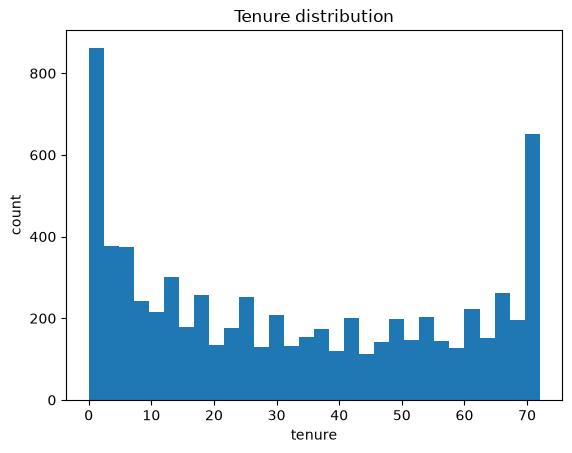

In [7]:
plt.hist(df["tenure"], bins=30)
plt.xlabel("tenure")
plt.ylabel("count")
plt.title("Tenure distribution")
plt.show()

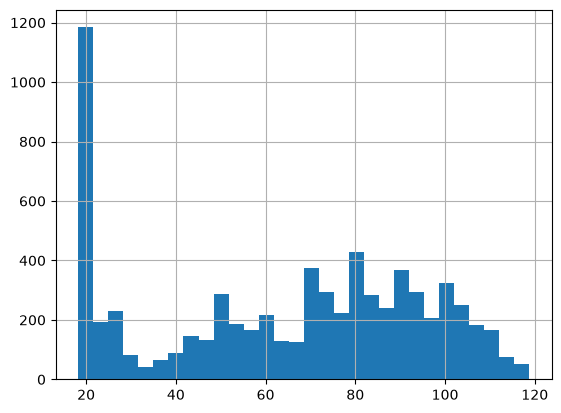

In [8]:
df["MonthlyCharges"].hist(bins=30)
plt.show()

## Target & Churn Relationships

In [9]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [10]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [11]:
df["Contract"].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

## Data Quality

In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [13]:
(df.astype(str).apply(lambda s: s.str.strip() == "")).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df["customerID"].duplicated().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [17]:
(df["tenure"] < 0).sum()

np.int64(0)

In [18]:
(df["MonthlyCharges"] <= 0).sum()

np.int64(0)

In [19]:
df["Churn"].value_counts(dropna=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
df.loc[df["InternetService"] == "No", ["OnlineSecurity", "TechSupport"]].value_counts()

OnlineSecurity       TechSupport        
No internet service  No internet service    1526
Name: count, dtype: int64

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [22]:
df["TotalCharges"].isna().sum()

np.int64(11)

### Categorical Consistency Checks

In [23]:
# --- Trailing / leading spaces in object columns ---
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols.drop("customerID"):
    raw = df[col].astype(str)
    stripped = raw.str.strip()
    n_bad = (raw != stripped).sum()
    if n_bad:
        print(f"{col}: {n_bad} values with leading/trailing spaces")
        print(df.loc[raw != stripped, col].value_counts().head())
        print()

C:\Users\Angelo\AppData\Local\Temp\ipykernel_6392\4187282065.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


In [24]:
# Unique values with repr() so spaces are visible
for col in obj_cols.drop("customerID"):
    print(col)
    for v in df[col].dropna().unique():
        print(" ", repr(v))
    print()


gender
  'Female'
  'Male'

Partner
  'Yes'
  'No'

Dependents
  'No'
  'Yes'

PhoneService
  'No'
  'Yes'

MultipleLines
  'No phone service'
  'No'
  'Yes'

InternetService
  'DSL'
  'Fiber optic'
  'No'

OnlineSecurity
  'No'
  'Yes'
  'No internet service'

OnlineBackup
  'Yes'
  'No'
  'No internet service'

DeviceProtection
  'No'
  'Yes'
  'No internet service'

TechSupport
  'No'
  'Yes'
  'No internet service'

StreamingTV
  'No'
  'Yes'
  'No internet service'

StreamingMovies
  'No'
  'Yes'
  'No internet service'

Contract
  'Month-to-month'
  'One year'
  'Two year'

PaperlessBilling
  'Yes'
  'No'

PaymentMethod
  'Electronic check'
  'Mailed check'
  'Bank transfer (automatic)'
  'Credit card (automatic)'

Churn
  'No'
  'Yes'



In [25]:
# --- Check for mixed / inconsistent encodings for "same idea" ---
# 1) Same meaning, different spellings/cases
for col in obj_cols:
    lowered = df[col].astype(str).str.strip().str.lower()
    print(col, "->", sorted(lowered.unique()))

customerID -> ['0002-orfbo', '0003-mknfe', '0004-tlhlj', '0011-igkff', '0013-exchz', '0013-mhzwf', '0013-smeoe', '0014-bmaqu', '0015-uocoj', '0016-qljis', '0017-dinoc', '0017-iudmw', '0018-nyrou', '0019-efaep', '0019-gfntw', '0020-inwck', '0020-jdnxp', '0021-ikxgc', '0022-tcjci', '0023-hghwl', '0023-uyupn', '0023-xuopt', '0027-kwykw', '0030-fnxpp', '0031-pvlzi', '0032-pgels', '0036-ihmot', '0040-halcw', '0042-jvwoj', '0042-rlhyp', '0048-lumls', '0048-pihnl', '0052-dckon', '0052-ynyot', '0056-epfbg', '0057-qbuqh', '0058-evzwm', '0060-fualy', '0064-sudog', '0064-yijgf', '0067-dkwbl', '0068-figtf', '0071-ndafp', '0074-hdkdg', '0076-lveps', '0078-xzmht', '0080-emyvy', '0080-orozo', '0082-ldzue', '0082-oqiqy', '0083-pivik', '0089-iiqko', '0093-exyql', '0093-xwzfy', '0094-oifmo', '0096-bxers', '0096-fcpuf', '0098-bowso', '0100-duvfc', '0103-csitq', '0104-ppxdv', '0106-ghrqr', '0106-ugrdo', '0107-weslm', '0107-yhina', '0111-klbqg', '0112-qawrz', '0112-qwpnc', '0114-igabw', '0114-pegzz', '0114

In [26]:
# 2) Yes/No style columns: look for unexpected levels
yes_no_like = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Churn",
]

for col in yes_no_like:
    print(col, df[col].value_counts(dropna=False).to_dict())

Partner {'No': 3641, 'Yes': 3402}
Dependents {'No': 4933, 'Yes': 2110}
PhoneService {'Yes': 6361, 'No': 682}
PaperlessBilling {'Yes': 4171, 'No': 2872}
MultipleLines {'No': 3390, 'Yes': 2971, 'No phone service': 682}
OnlineSecurity {'No': 3498, 'Yes': 2019, 'No internet service': 1526}
OnlineBackup {'No': 3088, 'Yes': 2429, 'No internet service': 1526}
DeviceProtection {'No': 3095, 'Yes': 2422, 'No internet service': 1526}
TechSupport {'No': 3473, 'Yes': 2044, 'No internet service': 1526}
StreamingTV {'No': 2810, 'Yes': 2707, 'No internet service': 1526}
StreamingMovies {'No': 2785, 'Yes': 2732, 'No internet service': 1526}
Churn {'No': 5174, 'Yes': 1869}


In [27]:
# 3) Logical consistency: "No internet" should not mix with Yes/No services
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
print(
    df.loc[df["InternetService"] == "No", service_cols]
    .apply(lambda s: s.unique())
)

        OnlineSecurity         OnlineBackup     DeviceProtection  \
0  No internet service  No internet service  No internet service   

           TechSupport          StreamingTV      StreamingMovies  
0  No internet service  No internet service  No internet service  


In [28]:
# 4) PhoneService vs MultipleLines consistency
print(
    df.groupby("PhoneService")["MultipleLines"]
    .value_counts(dropna=False)
)

PhoneService  MultipleLines   
No            No phone service     682
Yes           No                  3390
              Yes                 2971
Name: count, dtype: int64


## Churn Drivers

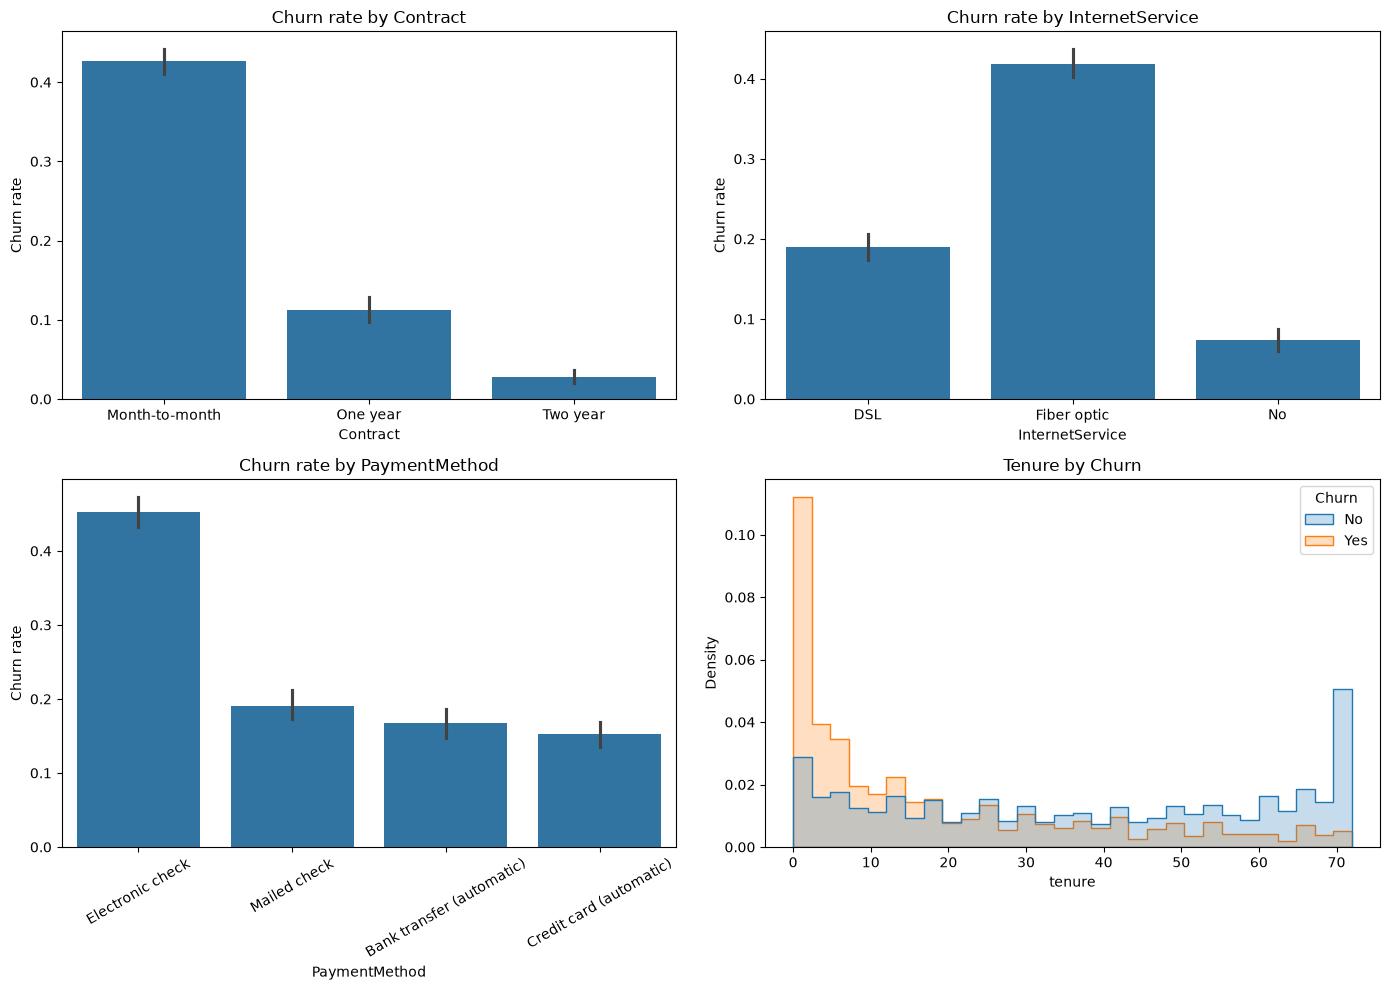

In [29]:
# Make Churn easy to use in plots
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Churn rate by Contract
contract_order = ["Month-to-month", "One year", "Two year"]
sns.barplot(
    data=df,
    x="Contract",
    y="ChurnFlag",
    order=contract_order,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Churn rate by Contract")
axes[0, 0].set_ylabel("Churn rate")

# 2) Churn rate by InternetService
sns.barplot(
    data=df,
    x="InternetService",
    y="ChurnFlag",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Churn rate by InternetService")
axes[0, 1].set_ylabel("Churn rate")

# 3) Churn rate by PaymentMethod
sns.barplot(
    data=df,
    x="PaymentMethod",
    y="ChurnFlag",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Churn rate by PaymentMethod")
axes[1, 0].set_ylabel("Churn rate")
axes[1, 0].tick_params(axis="x", rotation=30)

# 4) Tenure distribution by Churn
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    element="step",
    common_norm=False,
    stat="density",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Tenure by Churn")

plt.tight_layout()
plt.show()

Highest-risk profile: month-to-month, short tenure, fiber, electronic check, higher monthly charges.

Lowest-risk: long contract, long tenure, basic/low-charge plans.

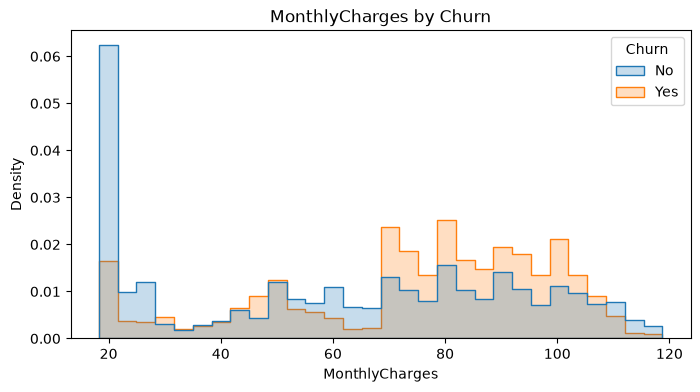

In [30]:
# Bonus: MonthlyCharges by Churn
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    element="step",
    common_norm=False,
    stat="density",
)
plt.title("MonthlyCharges by Churn")
plt.show()

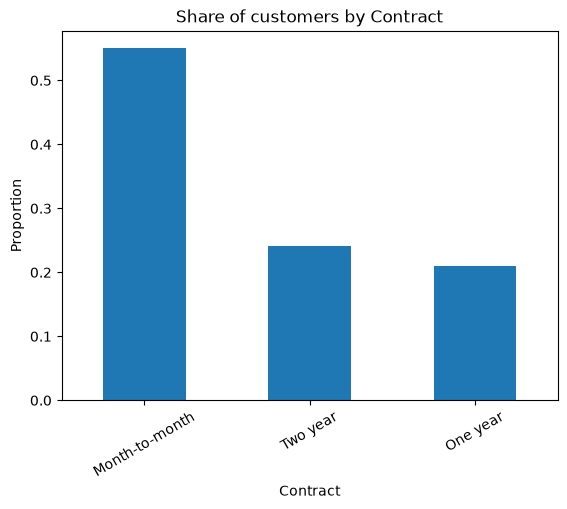

In [31]:


# Bonus: how common each contract is
df["Contract"].value_counts(normalize=True).plot(kind="bar")
plt.title("Share of customers by Contract")
plt.ylabel("Proportion")
plt.xticks(rotation=30)
plt.show()

## Key Findings

The Telco Customer Churn dataset is relatively clean and usable for modeling, with one notable data-quality issue in `TotalCharges`.

### Target and class balance
- Overall churn rate is about **26.5%** (`Yes`), so the dataset is moderately imbalanced.
- Accuracy alone will be misleading later; prefer ROC-AUC / PR-AUC and threshold-aware metrics.

### Strongest observed associations
- **Contract** is the clearest signal:
  - Month-to-month ≈ **43%** churn
  - One year ≈ **11%** churn
  - Two year ≈ **3%** churn
- Month-to-month is also the largest group (~**55%** of customers), so this matters both relatively and in absolute volume.
- **Tenure**: churn is concentrated among short-tenure customers; long-tenure customers mostly stay.
- **InternetService**: Fiber optic customers churn much more (~**42%**) than DSL (~**19%**) or no internet (~**7%**).
- **PaymentMethod**: Electronic check has much higher churn (~**45%**) than other methods (~**15–19%**).
- **MonthlyCharges**: low-charge customers (~$20) tend to stay; higher charges (~$70–110) have relatively more churn.

### Data quality
- No duplicate `customerID`s or duplicate rows.
- Categorical levels are consistent (no mixed spellings / trailing spaces found).
- Phone and internet service fields are logically consistent
  (`No phone service`, `No internet service` appear where expected).
- **`TotalCharges`** contains blank strings for a small number of customers. After numeric conversion, there are **11 missing values**, typically associated with `tenure == 0`.
- `SeniorCitizen` is coded as `0/1`, while other flags use `Yes`/`No` — not dirty, but important for preprocessing.
- `TotalCharges` is strongly correlated with `tenure` (and moderately with `MonthlyCharges`), which is expected because total spend accumulates over time.

### Caution
- These plots show **associations**, not causation.
- Fiber optic or electronic check may simply proxy for other factors (price, contract type, customer segment), not independently “cause” churn.
- Because features are correlated, univariate patterns can weaken or change once modeled jointly.

### Highest-risk profile (descriptive)
Month-to-month contract, short tenure, fiber optic, electronic check, higher monthly charges.

### Lowest-risk profile (descriptive)
Longer contract, long tenure, basic/low-charge plans.

### Next step
Moving to modeling with a stratified train/test split, leakage-safe preprocessing (`ColumnTransformer` + `Pipeline`), and proper evaluation beyond accuracy.